# 03 — Add your own measure

A measure is a decorated function; scoring it requires listing its name in the config taxonomy. This notebook adds a `woodwork` measure (shots off the post) to the chances family and rescores.

## How the index works, in one screen

The excitement index turns one soccer match into a single 0-10 rating, and it is built to be legible: every point is traceable to a named quantity.

1. **Measures.** Each measure is a small function that reads one match and returns a number — how many shots hit the post, how far the win probability swung, how long the result stayed within one goal, and so on. Measures are grouped into *families* (chances, keeping, drama, timing, ...).
2. **Feature matrix.** Running every measure over every match gives a table with one row per match and one column per measure. That is the feature matrix built below.
3. **Scoring.** `score_matches` standardizes each measure against a reference pool, weights it, applies two context deductions (a dead-rubber tax and a knockout aliveness tax), and folds the families into five display **buckets** — `stakes`, `chances`, `drama`, `spectacle`, `payoff` — that sum exactly to the raw score before it is mapped onto the 0-10 scale.
4. **Configuration.** Which families exist, and which measures belong to each, lives in `config/default.yaml` under `taxonomy`. Adding a measure therefore takes two steps: define the function, and list its name under a family in the taxonomy. This notebook does exactly that with a `woodwork` measure and rescores.

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath("../src"))
os.environ.setdefault("EXCITEMENT_INDEX_CACHE", os.path.abspath("../.opendata_cache"))
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
pd.set_option("display.width", 140)

### Setup

The cell above puts the package source on the path, points `EXCITEMENT_INDEX_CACHE` at a local folder where downloaded StatsBomb open-data is cached (so repeated event loads are fast), silences warnings, and widens pandas' console output. Nothing here touches the index itself — it is just environment plumbing so the imports below resolve to the in-repo `excitement_index` package rather than an installed copy.

In [2]:
from excitement_index.measures.registry import measure

@measure("woodwork")
def woodwork(ctx):
    """Shots that hit the post (excluding those saved onto it, which the
    goalkeeping family already credits)."""
    return float((ctx.shots["shot_outcome"] == "Post").sum())

### The measure: a decorated function

`@measure("woodwork")` registers the function under that name in the global measure registry. A measure receives a single `ctx` (a `MatchContext`) that exposes pre-filtered views of the match — here `ctx.shots`, the shot events — and returns one float. This measure counts shots whose `shot_outcome` is `"Post"`: balls that struck the woodwork and stayed out. Shots *saved onto* the post are recorded differently and are already credited by the goalkeeping family, so they are not double-counted here.

Registration happens at import/definition time. That is why simply running this cell is enough to make `woodwork` available to every feature build later in the session — no explicit list to update in code (only the config taxonomy, which we amend when we score).

New measures register at import time, so the feature build below picks `woodwork` up automatically. (Features must be rebuilt when the measure set changes — we rebuild just the knockouts here to keep it quick, then score the cached group-stage rows unchanged.)

In [3]:
from pathlib import Path
from excitement_index import opendata, build_feature_matrix

CACHE = Path("wc2022_features.parquet")
matches = opendata.load_matches("FIFA World Cup", "2022")
if CACHE.exists():
    features = pd.read_parquet(CACHE)
else:
    features = build_feature_matrix(matches, opendata.load_events,
                                    elo=opendata.load_elo(), jeopardy=False)
    features.to_parquet(CACHE)
print(features.shape)

(64, 64)


### Building (or loading) the feature matrix

`build_feature_matrix` runs every registered measure over all 64 matches and returns a table indexed by `match_id`. The printed shape `(64, 64)` is 64 matches by 64 columns (measures plus a few metadata columns like `home`, `away`, `stage`).

The cache is a convenience but also a trap worth naming: this cell reads `wc2022_features.parquet` if it exists, and that cached file was written **before** `woodwork` was registered, so it has no `woodwork` column. That is exactly why the next cell recomputes the matrix from scratch rather than trusting the cache. `jeopardy=False` skips the qualification-jeopardy pass here; it is copied over from the cached frame in the next cell.

In [4]:
from excitement_index import extract_features, opendata

# recompute features for every match so the new column exists everywhere
elo = opendata.load_elo()
rows = {}
for mid in features.index:
    row = matches[matches["match_id"] == mid].iloc[0]
    rows[mid] = extract_features(opendata.load_events(int(mid)), row, elo=elo)
features2 = pd.DataFrame.from_dict(rows, orient="index")
for c in ("home", "away", "stage"):
    features2[c] = features[c]
features2["qualification_jeopardy"] = features["qualification_jeopardy"]
print("woodwork counts:", features2["woodwork"].sum())

woodwork counts: 33.0


### Recomputing so the new column exists everywhere

Because the cached matrix predates `woodwork`, this cell calls `extract_features` on each match's events to rebuild the full measure set — now including `woodwork` — into `features2`. The metadata columns (`home`, `away`, `stage`) and the `qualification_jeopardy` value are carried over from the cached frame rather than recomputed. The printout `woodwork counts: 33.0` is the tournament-wide total: 33 shots hit the post and stayed out across the 2022 World Cup. Seeing a sensible, non-zero total is the quick check that the new measure is wired in correctly.

## Score with the new measure in the taxonomy

In [5]:
from excitement_index import score_matches, load_config

cfg = load_config()
tax = {k: list(v) for k, v in cfg["taxonomy"].items()}
tax["chances"] = tax["chances"] + ["woodwork"]
board2 = score_matches(features2, config={"taxonomy": tax})
board2[["home", "away", "rating"]].head(10)

,home,away,rating
3869685,Argentina,France,9.59
3869420,Croatia,Brazil,9.49
3857292,Costa Rica,Germany,9.47
3869321,Netherlands,Argentina,9.38
3869354,England,France,9.29
3857284,Germany,Japan,9.27
3857259,Cameroon,Serbia,9.06
3869219,Japan,Croatia,9.04
3857256,Serbia,Switzerland,8.87
3857262,South Korea,Portugal,8.70


### Reading the board

`load_config` reads the default taxonomy; the cell copies it and appends `"woodwork"` to the `chances` family, then rescores. Passing the amended taxonomy as a `config=` override is the second and final step of adding a measure — the function alone does nothing until a family claims it.

`board2` is sorted best-match-first. Alongside `home`/`away`/`rating` it also carries `raw` (the pre-scale score) and the five `bucket_*` columns, which sum to `raw`. The 2022 final (Argentina 3-3 France, then penalties) tops the board at 9.59, as expected. The figures below unpack what these numbers contain: the spread of ratings across the tournament, where one match's points come from, the win-probability history the drama measures read, and how individual measures relate to the final rating.

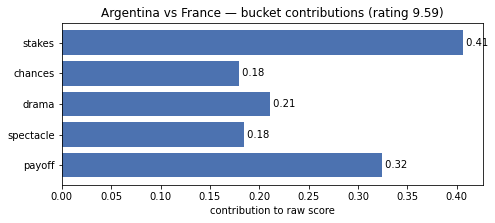

In [6]:
import matplotlib.pyplot as plt

mid = 3869685
row = board2.loc[mid]
buckets = ["stakes", "chances", "drama", "spectacle", "payoff"]
vals = [row[f"bucket_{b}"] for b in buckets]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.barh(buckets, vals, color="#4C72B0")
ax.invert_yaxis()  # first bucket on top
for i, v in enumerate(vals):
    ax.text(v, i, f" {v:.2f}", va="center")
ax.set_xlabel("contribution to raw score")
ax.set_title(f"{row['home']} vs {row['away']} — bucket contributions "
             f"(rating {row['rating']:.2f})")
fig.tight_layout()
plt.show()

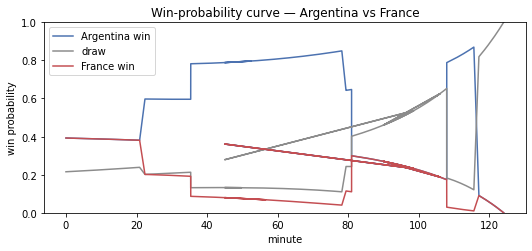

In [7]:
import matplotlib.pyplot as plt
from excitement_index import wp
from excitement_index.clock import resolve_team_name, playable_events

mid = 3869685
mrow = matches[matches["match_id"] == mid].iloc[0]
ev = opendata.load_events(mid)
teams = set(playable_events(ev)["team"].dropna().unique())
home = resolve_team_name(mrow["home"], teams)
away = resolve_team_name(mrow["away"], teams)

curve = wp.wp_curve(ev, home=home, away=away)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(curve["_t"], curve["p_home"], label=f"{home} win", color="#4C72B0")
ax.plot(curve["_t"], curve["p_draw"], label="draw", color="#8C8C8C")
ax.plot(curve["_t"], curve["p_away"], label=f"{away} win", color="#C44E52")
ax.set_xlabel("minute")
ax.set_ylabel("win probability")
ax.set_ylim(0, 1)
ax.set_title(f"Win-probability curve — {home} vs {away}")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()